In [58]:
import pandas as pd
import numpy as np
import os

In [59]:
print(os.getcwd())

c:\Users\priya\OneDrive\Desktop\NETWORKMED_PROJ\graph_network


In [60]:
ppi = pd.read_csv('../raw_data/protein_protein_link.txt.gz',sep=' ',compression='gzip')
ppi.head()

,protein1,protein2,combined_score
0,9606.ENSP00000000233,9606.ENSP00000257770,311
1,9606.ENSP00000000233,9606.ENSP00000226004,161
2,9606.ENSP00000000233,9606.ENSP00000434442,499
3,9606.ENSP00000000233,9606.ENSP00000262455,531
4,9606.ENSP00000000233,9606.ENSP00000303145,499


In [61]:
p_info = pd.read_csv('../raw_data/protein_info.txt.gz',sep='\t',compression='gzip')
p_info.head()

,#string_protein_id,preferred_name,protein_size,annotation
0,9606.ENSP00000000233,ARF5,180,ADP-ribosylation factor 5; GTP-binding protein...
1,9606.ENSP00000000412,M6PR,277,Cation-dependent mannose-6-phosphate receptor;...
2,9606.ENSP00000001008,FKBP4,459,"Peptidyl-prolyl cis-trans isomerase FKBP4, N-t..."
3,9606.ENSP00000001146,CYP26B1,512,Cytochrome P450 26B1; Involved in the metaboli...
4,9606.ENSP00000002125,NDUFAF7,441,"Protein arginine methyltransferase NDUFAF7, mi..."


In [62]:
name_map = p_info.set_index('#string_protein_id')['preferred_name']

In [63]:
ppi = ppi[ppi['combined_score']>=900]

In [64]:
ppi['protein1'] = ppi['protein1'].map(name_map)
ppi['protein2'] = ppi['protein2'].map(name_map)

ppi.head()

,protein1,protein2,combined_score
155,M6PR,IGF2R,900
210,M6PR,GGA3,970
254,FKBP4,PGR,926
272,FKBP4,FKBP5,970
283,FKBP4,HSP90AB1,995


In [65]:
import networkx as nx
import matplotlib.pyplot as plt


In [66]:
G = nx.from_pandas_edgelist(ppi, 
                            source='protein1', 
                            target='protein2', 
                            edge_attr='combined_score')

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Nodes: 8706
Edges: 44931


In [67]:
# plt.figure(figsize=(10, 8))

# # Use a spring layout to spread out the nodes
# pos = nx.spring_layout(G, k=0.5) 

# # Draw nodes and labels
# nx.draw(G, pos, with_labels=True, 
#         node_color='skyblue', 
#         node_size=800, 
#         font_size=10, 
#         edge_color='gray',
#         alpha=0.8)

# plt.title("Protein-Protein Interaction Network")
# plt.show()

it is not pssible to see grpah as number of nodes and edges are high , so we make only for one protein

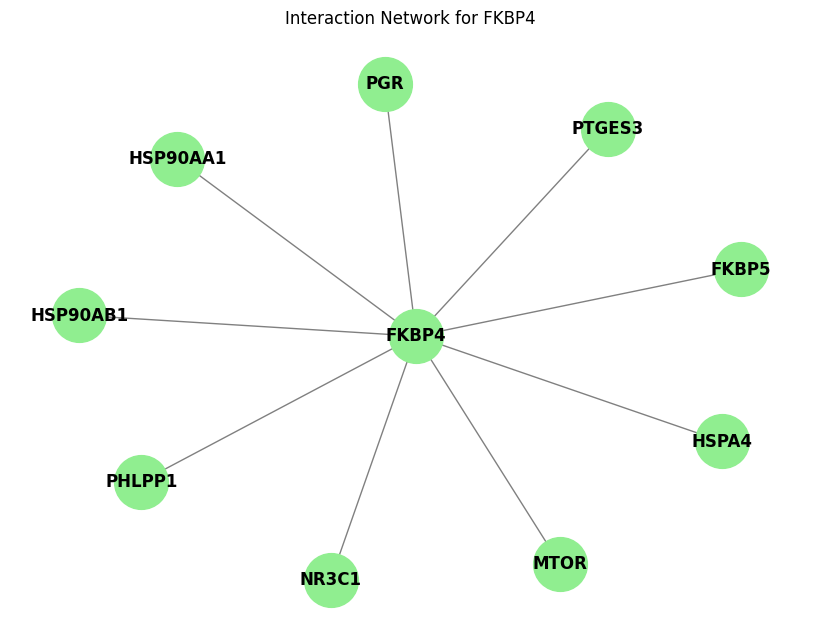

In [72]:

# 1. Pick your protein of interest
target_protein = 'FKBP4'

# 2. Find all rows where this protein appears
subset_df = ppi[(ppi['protein1'] == target_protein) | (ppi['protein2'] == target_protein)]

# 3. (Optional) Filter for strength so we don't get too many neighbors
# Let's take the top 20 strongest interactions for this protein
subset_df = subset_df.nlargest(20, 'combined_score')

# 4. Create the small graph
G_small = nx.from_pandas_edgelist(subset_df, 'protein1', 'protein2', 'combined_score')

# 5. Draw it
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_small, k=0.8) # k increases distance between nodes

nx.draw(G_small, pos, 
        with_labels=True, 
        node_color='lightgreen', 
        node_size=1500, 
        font_weight='bold',
        edge_color='gray')

plt.title(f"Interaction Network for {target_protein}")
plt.show()

In [69]:
print(ppi['protein1'].unique()[:20]) # This shows the first 20 unique names

<StringArray>
[    'M6PR',    'FKBP4',  'CYP26B1',    'FUCA2',   'SEMA3F',     'CFTR',
    'USP28',    'HSPB6',    'USH1C',     'RALA',   'CACNG3',     'DVL2',
    'RPAP3',    'SKAP2',   'CX3CL1', 'TRAPPC6A',     'CRY1',  'PGLYRP1',
 'STARD3NL',     'CD74']
Length: 20, dtype: str


In [70]:
target_protein = 'ARF5'

# Use .str.contains to be safer
subset_df = ppi[
    ppi['protein1'].astype(str).str.contains(target_protein, case=False, na=False) | 
    ppi['protein2'].astype(str).str.contains(target_protein, case=False, na=False)
]

print(f"Rows found: {len(subset_df)}")


Rows found: 0
